# 16 Resolution ML

This notebook models **two complementary targets** for flood-event resolution:

**Part A — Closure classification** (`resolution_bool`): did this flood event receive a formal service closure?

**Part B — Resolution-time regression** (`resolution`): among closed events, how many hours until closure?

Missing `resolution` is treated as censored / unresolved, **not** as zero. Part A models all observed events; Part B is restricted to `resolution.notna()`.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

observed flood events       : 34,870
closed (resolution.notna()) : 34,542
open / censored             : 328  ← these are NOT dropped; they inform Part A


,feature_group,expected_features,available_features,mean_non_null_rate,missing_features
0,event_time,8,8,0.998824,0
1,extra,18,18,0.999471,0
2,governance,3,3,1.000000,0
3,hydrometeorology,6,6,0.987104,0
4,infrastructure,4,4,0.500000,0
5,network,9,9,0.444444,0
6,socioeconomic,4,4,0.983589,0
7,spatial_controls,5,5,1.000000,0
8,targets,4,4,0.997648,0
9,terrain_coastal,8,8,0.999986,0


,feature_group,feature,available,dtype,non_null_rate,n_unique
0,event_time,day_of_week,True,Int64,1.000000,7
1,event_time,duration,True,float64,1.000000,7452
2,event_time,end,True,datetime64[us],0.990594,31625
3,event_time,hour,True,Int64,1.000000,24
4,event_time,month,True,Int64,1.000000,12
5,event_time,season,True,string,1.000000,4
6,event_time,start,True,datetime64[us],1.000000,32123
7,event_time,storm_event_id,True,string,1.000000,117
8,extra,catch_basin_nearest_ft,True,float64,1.000000,16985
9,extra,component_size,True,int64,1.000000,52


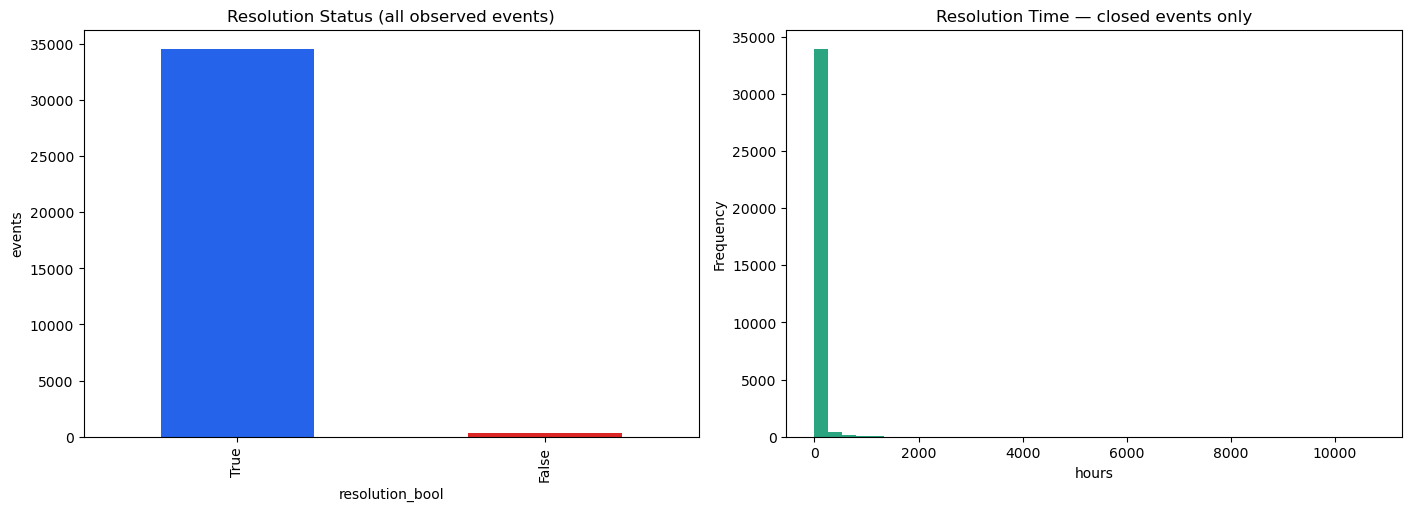

In [3]:
from project_name.modeling_stage import (
    RESOLUTION_BIAS_DIAGNOSTICS_PATH,
    RESOLUTION_CLOSURE_RESULTS_PATH,
    RESOLUTION_FEATURE_IMPORTANCE_PATH,
    RESOLUTION_LEAKAGE_AUDIT_PATH,
    RESOLUTION_PREDICTIONS_PATH,
    RESOLUTION_TIME_RESULTS_PATH,
    compact_modeling_summary,
    feature_catalog,
    load_modeling_frame,
    run_resolution_ml,
    summarize_feature_groups,
)

observed = load_modeling_frame(view_name="strict_main", include_geometry=False, observed_only=True)
closed = observed[observed["resolution"].notna()].copy()
open_or_censored = observed[observed["resolution"].isna()].copy()

print(f"observed flood events       : {len(observed):,}")
print(f"closed (resolution.notna()) : {len(closed):,}")
print(f"open / censored             : {len(open_or_censored):,}  ← these are NOT dropped; they inform Part A")
display(summarize_feature_groups(observed))
display(feature_catalog(observed).head(40))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
observed["resolution_bool"].astype("boolean").value_counts(dropna=False).plot.bar(
    ax=axes[0], color=["#2563EB", "#DC2626"]
)
axes[0].set_title("Resolution Status (all observed events)")
axes[0].set_xlabel("resolution_bool")
axes[0].set_ylabel("events")
pd.to_numeric(closed["resolution"], errors="coerce").plot.hist(
    ax=axes[1], bins=40, color="#059669", alpha=0.85
)
axes[1].set_title("Resolution Time — closed events only")
axes[1].set_xlabel("hours")
plt.show()


## Part A + B — Run models

`run_resolution_ml` runs closure classification (Part A) and resolution-time regression (Part B) in one call and saves all outputs.

In [4]:
closure_results, time_results, predictions, feature_importance = run_resolution_ml(observed)

print("=== Part A: Closure Classification ===")
display(compact_modeling_summary(closure_results, ["pr_auc", "recall", "balanced_accuracy"]).head(20))

print("=== Part B: Resolution-Time Regression ===")
display(compact_modeling_summary(time_results, ["mae", "rmse", "r2"]).head(20))
display(feature_importance.head(40))

print(f"saved: {RESOLUTION_CLOSURE_RESULTS_PATH}")
print(f"saved: {RESOLUTION_TIME_RESULTS_PATH}")
print(f"saved: {RESOLUTION_PREDICTIONS_PATH}")
print(f"saved: {RESOLUTION_FEATURE_IMPORTANCE_PATH}")
print(f"saved: {RESOLUTION_BIAS_DIAGNOSTICS_PATH}")
print("incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/")


/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: Ru

=== Part A: Closure Classification ===


,task_name,split_strategy,model_name,status,pr_auc,recall,balanced_accuracy,best_params,notes
0,resolution_closure,stratified_75_15_10,random_forest,ok,0.999379,0.994211,0.572863,"{""model__class_weight"": ""balanced"", ""model__ma...",Classic 75/15/10 stratified-random split. Stra...
1,resolution_closure,stratified_75_15_10,gradient_boosting,ok,0.999294,0.998842,0.514573,"{""model__learning_rate"": 0.03, ""model__max_dep...",Classic 75/15/10 stratified-random split. Stra...
2,resolution_closure,stratified_75_15_10,logistic_regression,ok,0.999253,1.000000,0.500000,"{""model__C"": 1.0, ""model__class_weight"": null}",Classic 75/15/10 stratified-random split. Stra...
3,resolution_closure,stratified_75_15_10,decision_tree,ok,0.998173,0.999711,0.515007,"{""model__criterion"": ""gini"", ""model__max_depth...",Classic 75/15/10 stratified-random split. Stra...


=== Part B: Resolution-Time Regression ===


,task_name,split_strategy,model_name,status,mae,rmse,r2,best_params,notes
0,resolution_time,temporal_by_administration,linear_regression,ok,100.188598,8960.911548,-11640.300230,{},Forward-looking temporal split by mayoral admi...
1,resolution_time,temporal_by_administration,ridge,ok,98.559395,8796.942715,-11218.167621,"{""model__alpha"": 100.0}",Forward-looking temporal split by mayoral admi...
2,resolution_time,stratified_75_15_10,ridge,ok,93.574932,3875.126994,-842.642414,"{""model__alpha"": 100.0}",Classic 75/15/10 stratified-random split. Stra...
3,resolution_time,stratified_75_15_10,linear_regression,ok,90.864410,3704.926327,-770.162104,{},Classic 75/15/10 stratified-random split. Stra...
4,resolution_time,stratified_75_15_10,dummy_regressor,ok,33.568394,135.256612,-0.027788,{},Classic 75/15/10 stratified-random split. Stra...
5,resolution_time,temporal_by_administration,dummy_regressor,ok,23.414144,83.812546,-0.018392,{},Forward-looking temporal split by mayoral admi...
6,resolution_time,stratified_75_15_10,random_forest_regressor,ok,22.337059,88.733612,0.557653,"{""model__max_depth"": null, ""model__max_feature...",Classic 75/15/10 stratified-random split. Stra...
7,resolution_time,stratified_75_15_10,gradient_boosting_regressor,ok,19.873659,58.518888,0.807612,"{""model__learning_rate"": 0.03, ""model__max_dep...",Classic 75/15/10 stratified-random split. Stra...
8,resolution_time,temporal_by_administration,random_forest_regressor,ok,18.790285,54.884425,0.563288,"{""model__max_depth"": null, ""model__max_feature...",Forward-looking temporal split by mayoral admi...
9,resolution_time,temporal_by_administration,gradient_boosting_regressor,ok,17.371358,35.646611,0.815781,"{""model__learning_rate"": 0.03, ""model__max_dep...",Forward-looking temporal split by mayoral admi...


,task_name,feature,importance,subtask
0,resolution_closure,mayoral_administration_bill_de_blasio_2014_2021,0.126608,closure_classification
1,resolution_closure,mayoral_administration_eric_adams_2022_2025,0.093640,closure_classification
2,resolution_closure,mayoral_administration_michael_bloomberg_2002_...,0.079829,closure_classification
3,resolution_closure,max_tide,0.059395,closure_classification
4,resolution_closure,mayoral_administration_zohran_mamdani_2026_pre...,0.057840,closure_classification
5,resolution_closure,census_median_household_income,0.040918,closure_classification
6,resolution_closure,census_renter_share,0.029814,closure_classification
7,resolution_closure,prec_depth_total,0.029473,closure_classification
8,resolution_closure,elevation,0.027819,closure_classification
9,resolution_closure,shore_dist,0.027655,closure_classification


saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/results_resolution_closure_ml.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/results_resolution_time_ml.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/predictions_resolution_ml.parquet
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/feature_importance_resolution.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/bias_diagnostics_resolution.csv
incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/


In [5]:
closure_results = pd.read_csv(RESOLUTION_CLOSURE_RESULTS_PATH)
time_results    = pd.read_csv(RESOLUTION_TIME_RESULTS_PATH)
predictions     = pd.read_parquet(RESOLUTION_PREDICTIONS_PATH)
feature_importance = pd.read_csv(RESOLUTION_FEATURE_IMPORTANCE_PATH)
bias            = pd.read_csv(RESOLUTION_BIAS_DIAGNOSTICS_PATH)
leakage_audit   = pd.read_csv(RESOLUTION_LEAKAGE_AUDIT_PATH)

closure_metric_cols = [
    "accuracy", "balanced_accuracy", "precision", "recall", "f1",
    "roc_auc", "pr_auc", "false_positive_rate", "false_negative_rate",
    "brier_score", "train_pr_auc", "validation_pr_auc", "test_pr_auc",
    "cv_validation_primary_score", "train_vs_validation_gap",
    "validation_vs_test_gap", "possible_overfitting", "possible_test_degradation",
]
time_metric_cols = [
    "rmse", "mae", "r2", "spearman_correlation", "pearson_correlation",
    "median_absolute_error", "train_mae", "validation_mae", "test_mae",
    "cv_validation_primary_score", "train_vs_validation_gap",
    "validation_vs_test_gap", "possible_overfitting", "possible_test_degradation",
]

print("=== Part A: Closure Classification ===")
display(
    closure_results[
        ["model_name", "split_strategy", "status"]
        + [c for c in closure_metric_cols if c in closure_results.columns]
    ].query("status == 'ok'")
)

print("=== Part B: Resolution-Time Regression ===")
display(
    time_results[
        ["model_name", "split_strategy", "status"]
        + [c for c in time_metric_cols if c in time_results.columns]
    ].query("status == 'ok'")
)

print("=== Bias Diagnostics ===")
display(bias.head(50))

print("=== Leakage Audit ===")
display(leakage_audit[leakage_audit["excluded_from_predictors"]].head(30))


=== Part A: Closure Classification ===


,model_name,split_strategy,status,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,false_negative_rate,brier_score,train_pr_auc,validation_pr_auc,test_pr_auc,cv_validation_primary_score,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
0,logistic_regression,stratified_75_15_10,ok,0.990539,0.500000,0.990539,1.000000,0.995247,0.927001,0.999253,1.000000,0.000000,0.008770,0.999339,0.999325,0.999253,0.999325,1.467833e-05,0.000072,False,False
1,decision_tree,stratified_75_15_10,ok,0.990539,0.515007,0.990820,0.999711,0.995246,0.890440,0.998173,0.969697,0.000289,0.009165,0.998416,0.998755,0.998173,0.998755,-3.392659e-04,0.000583,False,False
2,random_forest,stratified_75_15_10,ok,0.986239,0.572863,0.991915,0.994211,0.993062,0.938929,0.999379,0.848485,0.005789,0.013890,0.999998,0.999998,0.999379,0.999998,-1.109149e-07,0.000620,False,False
3,gradient_boosting,stratified_75_15_10,ok,0.989679,0.514573,0.990813,0.998842,0.994811,0.931632,0.999294,0.969697,0.001158,0.008934,0.999913,0.999976,0.999294,0.999976,-6.266677e-05,0.000682,False,False


=== Part B: Resolution-Time Regression ===


,model_name,split_strategy,status,rmse,mae,r2,spearman_correlation,pearson_correlation,median_absolute_error,train_mae,validation_mae,test_mae,cv_validation_primary_score,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
0,dummy_regressor,temporal_by_administration,ok,83.812546,23.414144,-0.018392,NaN,NaN,13.333333,34.884207,5.084170e+01,23.414144,-5.084170e+01,1.595750e+01,-2.742756e+01,True,False
1,linear_regression,temporal_by_administration,ok,8960.911548,100.188598,-11640.300230,0.009357,-0.001481,8.302527,48.217738,3.604641e+05,100.188598,-3.604641e+05,3.604159e+05,-3.603639e+05,True,False
2,ridge,temporal_by_administration,ok,8796.942715,98.559395,-11218.167621,0.009596,-0.001481,8.344446,46.357346,3.088062e+05,98.559395,-3.088062e+05,3.087598e+05,-3.087076e+05,True,False
3,random_forest_regressor,temporal_by_administration,ok,54.884425,18.790285,0.563288,0.005930,-0.009293,7.229773,14.298055,1.256314e+01,18.790285,-1.256314e+01,-1.734915e+00,6.227145e+00,False,True
4,gradient_boosting_regressor,temporal_by_administration,ok,35.646611,17.371358,0.815781,0.006475,-0.005659,7.267467,22.321829,1.728040e+01,17.371358,-1.728040e+01,-5.041433e+00,9.096153e-02,False,False
5,dummy_regressor,stratified_75_15_10,ok,135.256612,33.568394,-0.027788,NaN,NaN,13.216667,36.451957,4.140195e+01,33.568394,-4.140195e+01,4.949991e+00,-7.833554e+00,True,False
6,linear_regression,stratified_75_15_10,ok,3704.926327,90.864410,-770.162104,0.002711,-0.010606,8.704714,690.307375,6.189611e+06,90.864410,-6.189611e+06,6.188921e+06,-6.189521e+06,True,False
7,ridge,stratified_75_15_10,ok,3875.126994,93.574932,-842.642414,0.003758,-0.009648,8.653302,725.281747,5.015001e+06,93.574932,-5.015001e+06,5.014275e+06,-5.014907e+06,True,False
8,random_forest_regressor,stratified_75_15_10,ok,88.733612,22.337059,0.557653,-0.025261,-0.028802,5.998506,11.485320,1.287247e+01,22.337059,-1.287247e+01,1.387152e+00,9.464588e+00,True,True
9,gradient_boosting_regressor,stratified_75_15_10,ok,58.518888,19.873659,0.807612,-0.003958,-0.025330,6.183590,15.637508,1.587226e+01,19.873659,-1.587226e+01,2.347494e-01,4.001401e+00,True,True


=== Bias Diagnostics ===


,task_name,set_name,bias_dimension,group_value,n,mean_residual,median_residual,mae,underprediction_rate
0,resolution_time,test,borough,BRONX,5880,-1.341686e-01,-1.899237,9.123062e+00,0.332823
1,resolution_time,test,borough,BROOKLYN,24880,3.816367e+00,-1.317147,1.639611e+01,0.425683
2,resolution_time,test,borough,MANHATTAN,5720,1.872697e+00,-3.904019,1.530361e+01,0.249476
3,resolution_time,test,borough,QUEENS,32325,-5.632321e+01,2.279007,1.042490e+02,0.575159
4,resolution_time,test,borough,STATEN ISLAND,11265,9.905002e+00,0.534068,1.991813e+01,0.521438
5,resolution_time,train,borough,BRONX,12655,4.141172e+00,-0.279583,1.419777e+01,0.445990
6,resolution_time,train,borough,BROOKLYN,47915,1.220079e+01,0.164600,1.944924e+01,0.510926
7,resolution_time,train,borough,MANHATTAN,16025,1.856001e+01,0.499530,2.933975e+01,0.536661
8,resolution_time,train,borough,QUEENS,66695,-5.079980e+02,0.137062,5.624655e+02,0.509483
9,resolution_time,train,borough,STATEN ISLAND,29090,1.390276e+01,0.445395,2.224574e+01,0.524201


=== Leakage Audit ===


,feature,excluded_from_predictors,reason,dtype,non_null_rate
0,analysis_view_name,True,identifier_or_derived_selection,str,1.000000
1,catch_basin_nearest_ft,True,technical_duplicate_use_canonical_feature_name...,float64,1.000000
2,dataset_split_role,True,identifier_or_derived_selection,string,1.000000
3,dem_mean,True,technical_duplicate_use_canonical_feature_name...,float64,0.999943
4,dem_slope,True,technical_duplicate_use_canonical_feature_name...,float64,0.999943
5,duration,True,derived_from_event_end_and_target_related,float64,1.000000
6,end,True,close_time_target_related,datetime64[us],0.990594
7,event_end_local,True,technical_duplicate_use_canonical_feature_name...,datetime64[us],0.990594
8,event_id,True,identifier_or_derived_selection,string,1.000000
9,event_month,True,technical_duplicate_use_canonical_feature_name...,Int64,1.000000


## Archetype and Anomaly Error Diagnostics

The cluster output is especially useful for resolution-time inference because some event regimes may create larger service delays.
We use clusters and anomaly scores for diagnostics after prediction, not as the default regression target construction.

In [6]:
CLUSTER_PATH = ROOT / "data" / "processed" / "modeling" / "clustering_event_archetypes.parquet"
ANOMALY_PATH = ROOT / "data" / "processed" / "modeling" / "anomaly_event_scores.parquet"

if CLUSTER_PATH.exists() and ANOMALY_PATH.exists():
    clusters = pd.read_parquet(CLUSTER_PATH)[
        ["event_id", "combined_cluster_id", "cluster_label"]
    ].copy()
    anomalies = pd.read_parquet(ANOMALY_PATH)[
        ["event_id", "anomaly_score", "anomaly_flag", "anomaly_method_agreement"]
    ].copy()
    resolution_cluster_diag = (
        predictions.merge(clusters, on="event_id", how="left")
        .merge(anomalies, on="event_id", how="left")
    )
    resolution_cluster_diag = resolution_cluster_diag[resolution_cluster_diag["set_name"].eq("test")].copy()
    resolution_cluster_diag["residual"] = resolution_cluster_diag["y_true"] - resolution_cluster_diag["y_pred"]
    resolution_cluster_diag["absolute_error"] = resolution_cluster_diag["residual"].abs()
    resolution_by_cluster = (
        resolution_cluster_diag.groupby(["combined_cluster_id", "cluster_label"], dropna=False)
        .agg(
            n_events=("event_id", "size"),
            mae_hours=("absolute_error", "mean"),
            mean_residual_hours=("residual", "mean"),
            underprediction_rate=("residual", lambda s: pd.Series(s).gt(0).mean()),
            mean_anomaly_score=("anomaly_score", "mean"),
            anomaly_share=("anomaly_flag", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        )
        .reset_index()
        .sort_values("mae_hours", ascending=False, kind="stable")
    )
    resolution_by_cluster.to_csv(
        ROOT / "data" / "processed" / "modeling" / "diagnostics_resolution_by_cluster.csv",
        index=False,
    )
    display(resolution_by_cluster)
else:
    print("Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.")

Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.


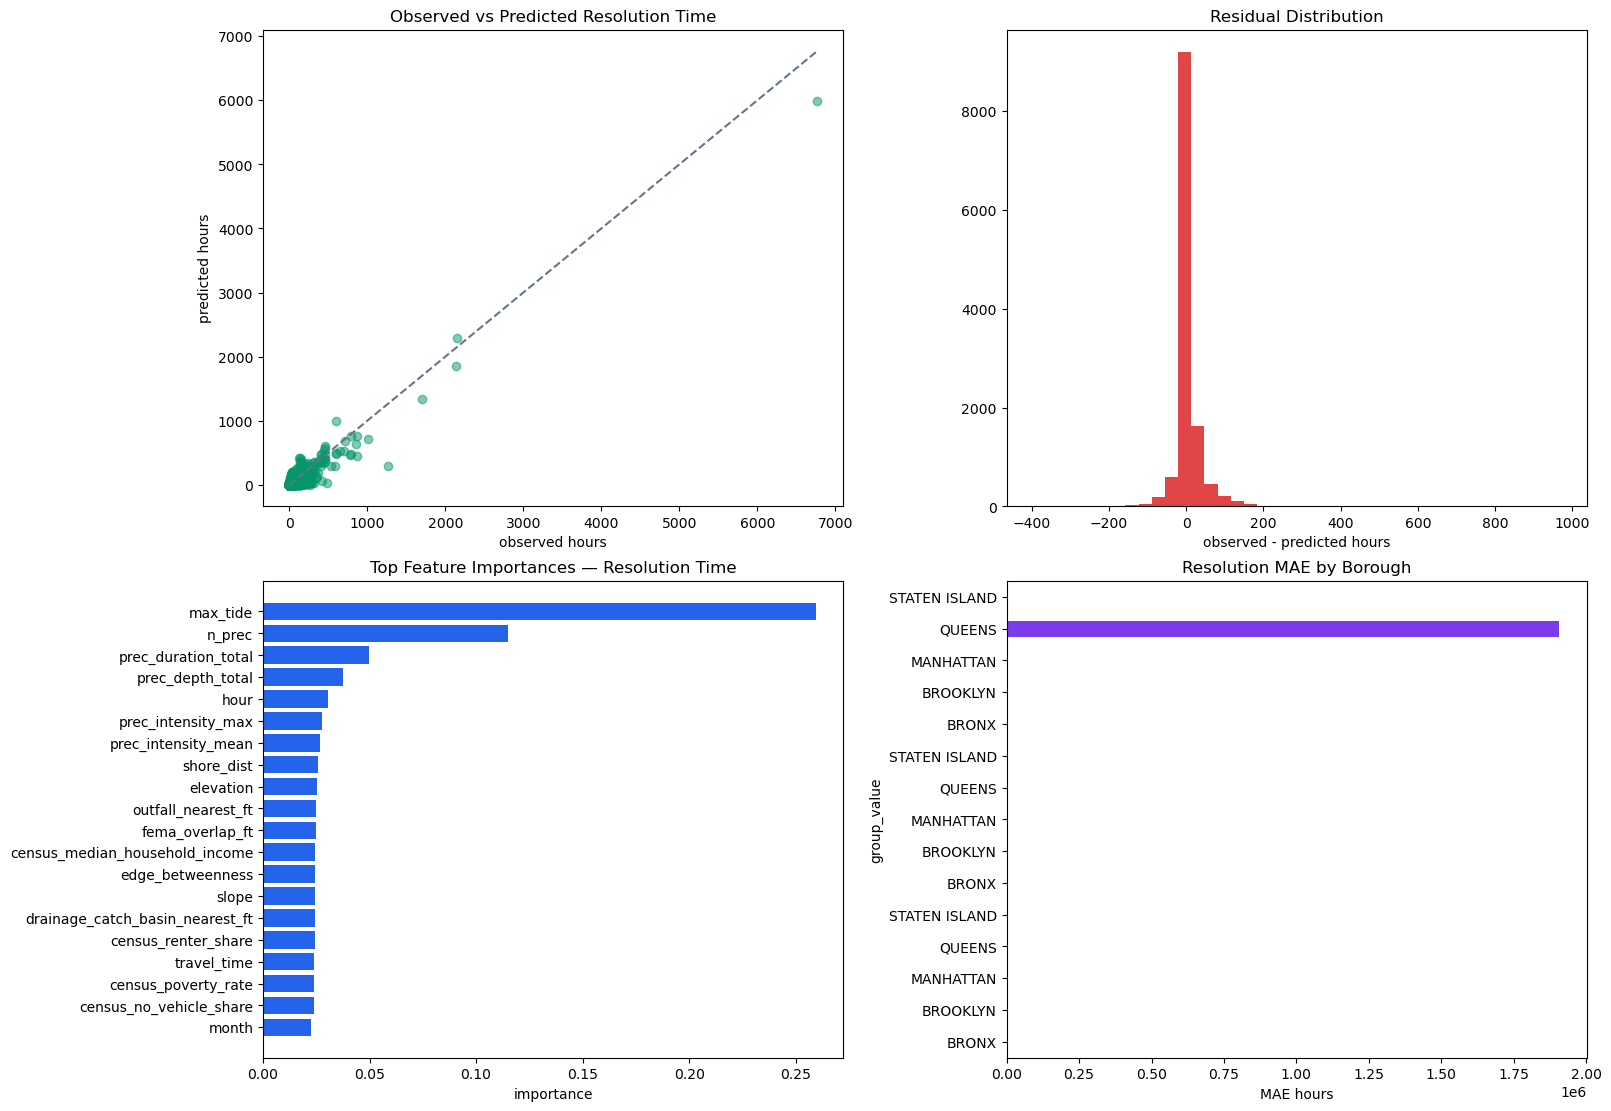

In [7]:
best_row = (
    time_results.query("status == 'ok'")
    .sort_values(["mae", "rmse"], ascending=[True, True], kind="stable")
    .iloc[0]
)
best_predictions = predictions[
    (predictions["model_name"] == best_row["model_name"])
    & (predictions["split_strategy"] == best_row["split_strategy"])
    & (predictions["set_name"] == "test")
    & (predictions["target"] == "resolution")
].copy()
best_predictions["residual"] = best_predictions["y_true"] - best_predictions["y_pred"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes[0, 0].scatter(best_predictions["y_true"], best_predictions["y_pred"], alpha=0.5, color="#059669")
axes[0, 0].plot(
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    linestyle="--",
    color="#64748B",
)
axes[0, 0].set_title("Observed vs Predicted Resolution Time")
axes[0, 0].set_xlabel("observed hours")
axes[0, 0].set_ylabel("predicted hours")

axes[0, 1].hist(pd.to_numeric(best_predictions["residual"], errors="coerce").dropna(), bins=40, color="#DC2626", alpha=0.85)
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("observed - predicted hours")

top_features = (
    feature_importance[feature_importance["subtask"] == "resolution_time_regression"]
    .head(20)
    .sort_values("importance", kind="stable")
)
axes[1, 0].barh(top_features["feature"], top_features["importance"], color="#2563EB")
axes[1, 0].set_title("Top Feature Importances — Resolution Time")
axes[1, 0].set_xlabel("importance")

bias.query("bias_dimension == 'borough'").plot.barh(x="group_value", y="mae", ax=axes[1, 1], color="#7C3AED", legend=False)
axes[1, 1].set_title("Resolution MAE by Borough")
axes[1, 1].set_xlabel("MAE hours")
plt.show()